# OpenStreetMap

In [1]:
import geopandas as gpd

## Carga de datos

In [2]:
path_pbf = 'osm/andalucia-260305.osm.pbf'

# 1. Extraer el polígono de la Provincia de Cádiz (Admin Level 6)
provincia_cadiz = gpd.read_file(
    path_pbf,
    engine='pyogrio',
    layer='multipolygons',
    where="admin_level = '6' AND name = 'Cádiz'"
)

# 2. Extraer todos los municipios (Admin Level 8) de Andalucía
municipios_and = gpd.read_file(
    path_pbf,
    engine='pyogrio',
    layer='multipolygons',
    where="admin_level = '8'"
)

In [3]:
provincia_cadiz

,osm_id,osm_way_id,name,type,aeroway,amenity,admin_level,barrier,boundary,building,...,man_made,military,natural,office,place,shop,sport,tourism,other_tags,geometry
0,349017,None,Cádiz,boundary,None,None,6,None,administrative,None,...,None,None,None,None,province,None,None,None,"""ISO3166-2""=>""ES-CA"",""ine:provincia""=>""11"",""na...","MULTIPOLYGON (((-5.27354 36.292, -5.2736 36.29..."


In [3]:
# Es vital que ambos tengan el mismo Sistema de Referencia (CRS)
# Generalmente OSM viene en EPSG:4326
municipios_and = municipios_and.to_crs(provincia_cadiz.crs)

# Realizamos la unión espacial
# 'inner' para quedarnos solo con los que coinciden
# 'within' asegura que el municipio esté dentro de la provincia
municipios_cadiz = gpd.sjoin(municipios_and, provincia_cadiz, predicate='within', how='inner')

# Limpiar columnas duplicadas tras el join (opcional)
municipios_cadiz = municipios_cadiz[['name_left', 'geometry']]
municipios_cadiz.columns = ['name', 'geometry']

In [4]:
municipios_cadiz.reset_index(drop=True, inplace=True)

In [6]:
municipios_cadiz.head(10)

,name,geometry,bbox
0,Paterna de Rivera,"MULTIPOLYGON (((-5.89546 36.53537, -5.87899 36...","(-5.8954597, 36.4971526, -5.8285846, 36.5382019)"
1,Olvera,"MULTIPOLYGON (((-5.10919 36.9607, -5.11265 36....","(-5.417881, 36.8701671, -5.0956924, 37.0373629)"
2,El Puerto de Santa María,"MULTIPOLYGON (((-6.29791 36.61689, -6.29768 36...","(-6.323047, 36.5274471, -6.1396142, 36.7189243)"
3,Prado del Rey,"MULTIPOLYGON (((-5.5232 36.8359, -5.52396 36.8...","(-5.599987, 36.7330958, -5.5001346, 36.8359545)"
4,Jimena de la Frontera,"MULTIPOLYGON (((-5.35545 36.4338, -5.35746 36....","(-5.5880574, 36.3437703, -5.3441085, 36.5377821)"
5,Jerez de la Frontera,"MULTIPOLYGON (((-5.89105 36.84219, -5.89186 36...","(-6.3061225, 36.5162096, -5.4557904, 36.8637895)"
6,Medina Sidonia,"MULTIPOLYGON (((-5.98013 36.51854, -5.97666 36...","(-6.0725169, 36.2150926, -5.616249, 36.5354686)"
7,La Línea de la Concepción,"MULTIPOLYGON (((-5.34987 36.223, -5.35282 36.2...","(-5.3708792, 36.1528423, -5.3105786, 36.2465604)"
8,Puerto Serrano,"MULTIPOLYGON (((-5.43895 36.93529, -5.43913 36...","(-5.5506207, 36.8934473, -5.4200851, 37.0524453)"
9,Puerto Real,"MULTIPOLYGON (((-6.23374 36.52908, -6.23596 36...","(-6.2591065, 36.4557889, -5.9801308, 36.5993865)"


Total municipios encontrados en Cádiz: 45
Límites de San Fernando: (-6.241792, 36.3786126, -6.1682303, 36.5099605)


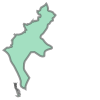

In [7]:
# Ejemplo de visualización rápida de San Fernando
print(f"Total municipios encontrados en Cádiz: {len(municipios_cadiz)}")
print(f"Límites de {municipios_cadiz.loc[29]['name']}: {municipios_cadiz.loc[29]['bbox']}")
display(municipios_cadiz.loc[29].geometry)

In [5]:
municipios_cadiz.iloc[0].get('name')

'Paterna de Rivera'

In [ ]:
for idx, data in municipios_cadiz.iterrows():
    print(f"{municipios_cadiz.iloc[idx].get('name')}: {municipios_cadiz.iloc[idx].geometry.area:.5f}")

Paterna de Rivera: 0.00141
Olvera: 0.01966
El Puerto de Santa María: 0.01606
Prado del Rey: 0.00490
Jimena de la Frontera: 0.02981
Jerez de la Frontera: 0.11978
Medina Sidonia: 0.04907
La Línea de la Concepción: 0.00268
Puerto Serrano: 0.00810
Puerto Real: 0.01974
Algar: 0.00273
Alcalá del Valle: 0.00475
Alcalá de los Gazules: 0.04821
Barbate: 0.01435
Arcos de la Frontera: 0.05319
Algodonales: 0.01355
Algeciras: 0.00880
Benaocaz: 0.00694
Los Barrios: 0.03321
Zahara: 0.00732
Villamartín: 0.02141
Villaluenga del Rosario: 0.00600
Torre Alháquime: 0.00177
Trebujena: 0.00708
Setenil de las Bodegas: 0.00830
Tarifa: 0.04200
Sanlúcar de Barrameda: 0.01726
San Roque: 0.01398
Rota: 0.00850
San Fernando: 0.00304
Ubrique: 0.00709
Vejer de la Frontera: 0.02634
San José del Valle: 0.02254
Benalup-Casas Viejas: 0.00609
El Gastor: 0.00279
Grazalema: 0.01236
Conil de la Frontera: 0.00882
Chiclana de la Frontera: 0.02066
Chipiona: 0.00330
Espera: 0.01248
Bornos: 0.00549
El Bosque: 0.00310
Cádiz: 0.00125

Ya tenemos un GeoDataframe con los municipios de Cádiz, el polígono que define sus límites administrativos y su bounding box correspondiente

# Copernicus

Mi intención era, en principio, utilizar Copernicus para obtener las distintas bandas de las imágenes satelitales y poder crear el indice de vegetación de cada provincia. Para mi sorpresa la resolución de las imágenes del Sentinel (satélite de Copernicus) es de 1 pixel por cada 100 m^2 (cuadrado de 10 metros por 10 metros). Esto hace que un árbol o incluso varios árboles queden reducidos a "No vegetacion" en caso de estar rodeado de pavimento.

La única solución posible era utilizarlo y reconocer que habrá un margen de error. Pero la solución no era esa...

Gracias al [cnig](https://centrodedescargas.cnig.es/CentroDescargas/resultados-busqueda) podemos descargar imágenes satelitales con resolución de hasta 0.25 metros buscando: "Ortofotos PNOA Máxima Actualidad". Pero el proceso de descarga será más tedioso que el de Copernicus

# CNIG

No es tan sencillo como en copernicus. Aquí no puedes buscar por coordenadas, tienes que buscar por cuadrantes. Por ejemplo para el cuadrante de San Fernando (Cádiz) he tenido que descargarme un [PDF de actualización de cuadrantes](files/20240513_ACTUALIZACIÓN_MA_118_MAD.pdf) donde se puede ver que es el número 1068, el cuadrante 2. Como el buscador es una atrocidad al intelecto humano utilizamos la vieja confiable de los indexados de Google: "1068-2 site:https://centrodedescargas.cnig.es" y mágicamente nos aparece nuestro archivo de San Fernando. Lo malo es que es de 2023, pero creo que se puede compensar con la ganacia de resolución.

Parece ser que con eso no me valía, porque me estaba dando otro archivo. Hay que meterse en el [visor de mapa](https://centrodedescargas.cnig.es/CentroDescargas/buscar-mapa) y en "Buscar por punto" seleccionas el punto de San Fernando. Ahí en la parte de "Imágenes aéreas y satelitales" puedes incluso descargar las de Sentinel-2 o buscar en "Ortofotos ..."

## Imágenes necesarias

Copernicus te permitía descargar un cuadrante de la anchura y de la altura que tu quisieras. Pero con CNIG al estar divididos por cuadrantes es necesario descargarse (para el caso de uso de la pronvicia de Cádiz) aproximadamente (aún no lo se con total seguridad) 74 cuadrantes.

Los cuadrantes necesarios pueden verse en la siguiente imagen coloreados de azul.

![Imagen cuadrantes necesarios provincia de Cádiz](./files/cuadrantes-necesarios.png)

## Zona de prueba

In [10]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import sys

In [12]:
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [ ]:
# https://centrodedescargas.cnig.es/CentroDescargas/detalleArchivo?sec=11369831
raw_image = rasterio.open('cnig/PNOA_MA_IRG_OF_ETRS89_HU29_h25_1068_2.tif')

imagen_falso_infrarrojo = raw_image.read(
    out_shape=(raw_image.count, int(raw_image.height / 10), int(raw_image.width / 10)),
    resampling=rasterio.enums.Resampling.bilinear,
    out_dtype='float16'
)
imagen_falso_infrarrojo_o = raw_image.read(
    out_dtype='float16',
)

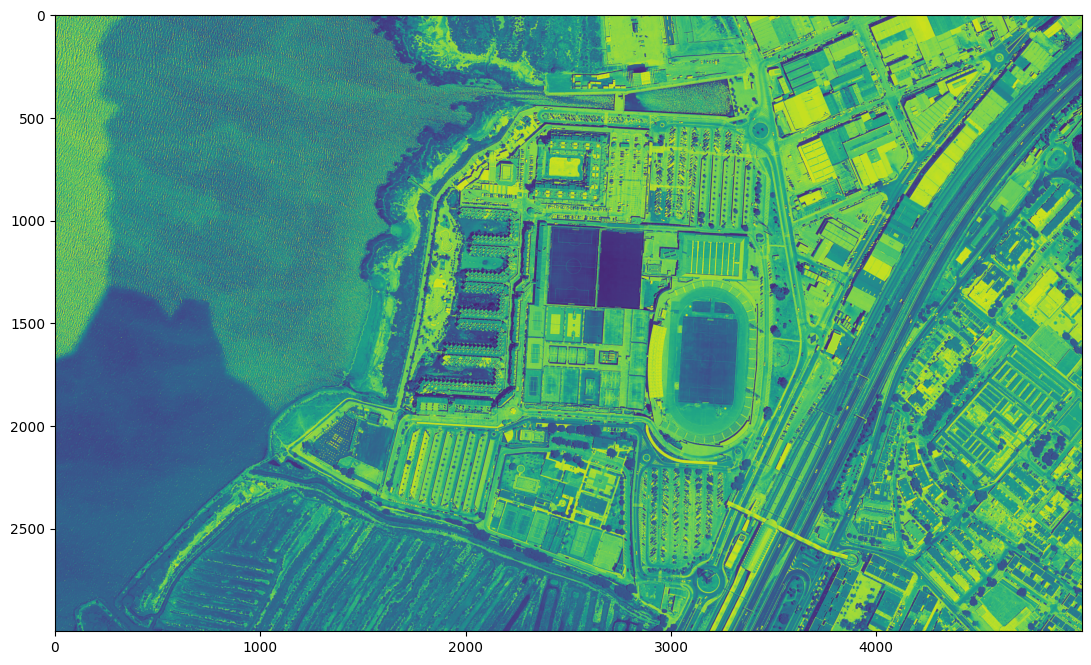

In [12]:
plt.figure(figsize=(14,8))
show(
    imagen_falso_infrarrojo_o[2][12000:15000, 50000:55000]
    # imagen_falso_infrarrojo[2][1200:1500, 5000:5500]
)
plt.show()

Como podemos ver aquí se puede ver mar a la izquierda, varios campos de fútbol, pero solo el de la izquierda es de césped natural, los dos mas pequeños son de cesped artificial. Así como justo a la derecha del campo de césped natural tenemos varios árboles.

Las bandas que tenemos son:

* 0: NIR

* 1: Red

* 2: Green

In [25]:
band_0 = imagen_falso_infrarrojo[0].astype('float16')
band_1 = imagen_falso_infrarrojo[1].astype('float16')
band_2 = imagen_falso_infrarrojo[2].astype('float16')
band_0_o = imagen_falso_infrarrojo_o[0].astype('float16')
band_1_o = imagen_falso_infrarrojo_o[1].astype('float16')
band_2_o = imagen_falso_infrarrojo_o[2].astype('float16')

In [45]:
band_0_o_cut = band_0_o[12000:15000, 50000:55000]
band_1_o_cut = band_1_o[12000:15000, 50000:55000]
band_2_o_cut = band_2_o[12000:15000, 50000:55000]

### Green NDVI

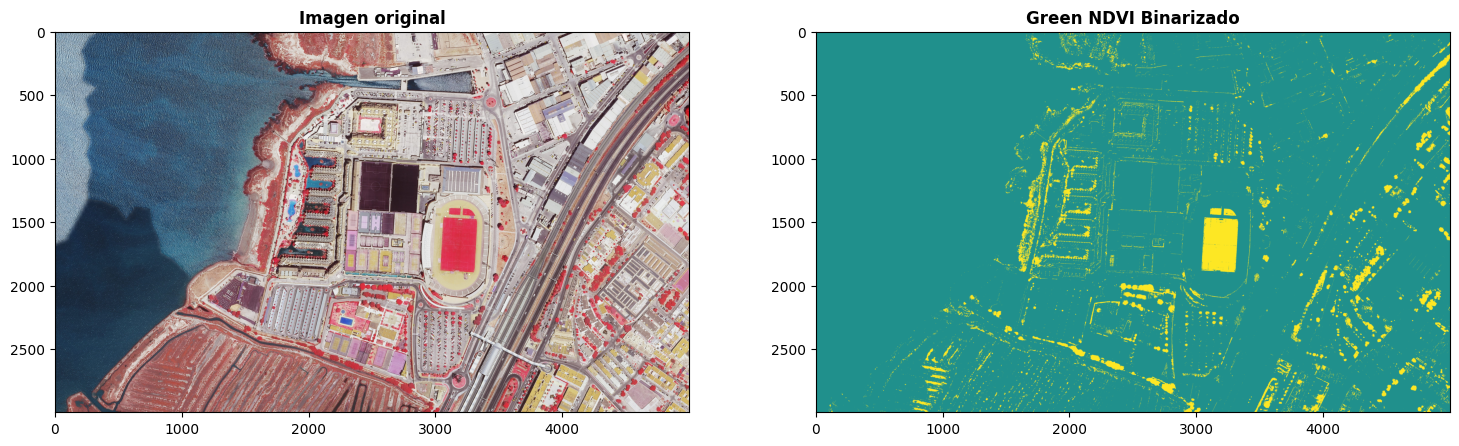

In [15]:
green_ndvi_cut_o = (band_0_o_cut - band_2_o_cut) / (band_0_o_cut + band_2_o_cut)
np.nan_to_num(green_ndvi_cut_o, nan=-1, copy=False)

green_ndvi_cut = green_ndvi_cut_o >= 0.35

plt.figure(figsize=(18,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
show(
    imagen_falso_infrarrojo_o[:, 12000:15000, 50000:55000],
    title='Imagen original',
    # cmap='RdYlGn',
    ax=ax1,
    vmin=-1,
    vmax=1,
)
show(
    green_ndvi_cut,
    title='Green NDVI Binarizado',
    ax=ax2,
    vmin=-1,
    vmax=1,
)
plt.show()

Como podemos ver en la imagen de la izquierda solamente el campo de césped natural aparece marcado por el índice GreenNDVI. Además de los árboles que se encuentran a su lado derecho en la imagen.

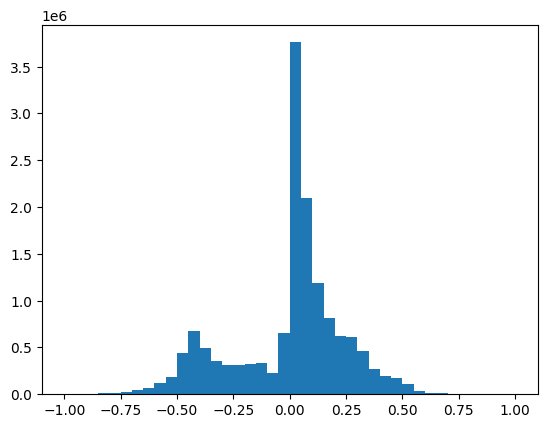

In [16]:
plt.hist(
    np.hstack(green_ndvi_cut_o),
    bins=40,
)
plt.show()

In [27]:
green_ndvi = (band_0_o - band_2_o) / (band_0_o + band_2_o)

In [28]:
green_ndvi = green_ndvi >= 0.35

In [29]:
green_ndvi = green_ndvi.astype('int8')

In [31]:
sys.getsizeof(green_ndvi) / (1024**3)

2.2412110567092896

In [32]:
# Metadatos de la imagen original
fichero_prueba_green_ndvi = rasterio.open(
    'test/green_ndvi_sanfernando.tif',
    'w',
    driver='GTiff',
    height=green_ndvi.shape[0],
    width=green_ndvi.shape[1],
    count=1,
    dtype='uint8',
    crs=raw_image.crs,
    transform=raw_image.transform,
    compress='lzw', # Compresión sin pérdida
    tiled=True # Permite abrirlo rápido en QGIS
)

fichero_prueba_green_ndvi.write(green_ndvi, 1)
fichero_prueba_green_ndvi.close()

# VRT

Como comenté anteriormente necesito aproximadamente 74 archivos .tiff para cubrir toda la provincia de Cádiz. Solamente el archivo que he utilizado de prueba para una gran parte del límite administrativo de San Fernando (el cual contenía aproximadamente un 10%/20% de nulos) pesa unos 500MB, lo que supondría que en total necesitaría ~36GB de archivos en 74 archivos distintos.

Esto en disco duro es algo aceptable, pero si quisieramos unir todos estos archivos y tenerlos en uno solo, esto requeriría de mucha RAM para alojar todos estos datos y aún más para el cálculo de los coeficientes necesarios.

Para esto existen los archivos VRT (Virtual Raster) que son capaces de, teniendo varios archivos GeoTIFF en disco, solamente cargar en memoria la parte que necesitas.

Pongamos que tengo ya los 74 archivos necesarios, y solamente me hace falta la parte correspondiente al límite administrativo de Puerto Real. Con todos los archivos GeoTIFF más el archivo VRT, conseguimos que solamente cargue en memoria los píxeles correspondientes a Puerto Real. Esto lo conseguimos mediante el polígono de coordenadas que hemos sacado de OSM, que utilizaremos como máscara.

Para unir los archivos he utilizado un comando que viene instalado con [QGIS](https://qgis.org/). Primero debes abrir la aplicacion `OSGeo4W Shell` y hacer uso del comando `gdalbuildvrt`. Este crea el archivo .vrt con un simple comando:

```shell
gdalbuild output.vrt file1.tif file2.tif
```

In [71]:
from rasterio.mask import mask

with rasterio.open("cnig/provincia_cadiz.vrt") as src:
    raster_crs = src.crs
    municipio_crs = municipios_cadiz.iloc[29:30].to_crs(raster_crs)
    geometria = [municipio_crs.geometry.values[0]]
    out_image_mask, out_transform = mask(src, geometria, crop=True, filled=False)
    out_image = out_image_mask.astype('float16').filled(np.nan)

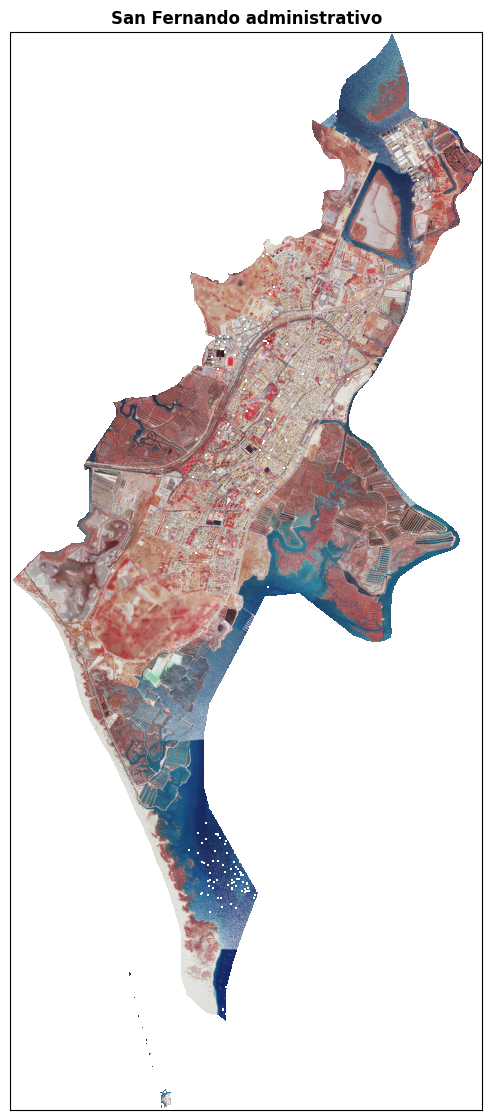

In [66]:
plt.figure(figsize=(14,14))
plt.xticks([])
plt.yticks([])
show(
    out_image[:, ::16, ::16],
    title='San Fernando administrativo',
)
plt.show()

Tras hacer una prueba para unificar todos los archivos `.tif` en un solo archivo VRT me ha dado el siguiente error:

```shell
Warning 1: gdalbuildvrt does not support heterogeneous projection: expected ETRS89 / UTM zone 29N, got ETRS89 / UTM zone 30N.
```

Esto es debido a que hay varios archivos en el huso 29 y otros en el 30. Para esto es necesario reproyectar por ejemplo los del huso 30 para ser del huso 29 y entonces poder unirlos de manera correcta.

Para esto primero crearemos un archivo `.vrt` por cada grupo de archivos de cada huso diferente (29 y 30). Luego reproyectaremos, por ejemplo, el archivo `.vrt` del huso 30 al huso 29 con el siguiente comando:

```shell
gdalwarp -of VRT -t_srs EPSG:25829 -ot Byte -r bilinear zona30.vrt zona30_en_29.vrt
```

Por último simplemente unimos la zona 29 con la zona 30 convertida a 29 con:

```shell
gdalbuildvrt -srcnodata 0 -vrtnodata 0 provincia_final.vrt parte_29.vrt parte_30_reproyectada.vrt
```

Los parámetros de srcnodata y vrtnodata son para que las uniones entre husos no se sobrepongan con un color negro, si no que transparente la capa siguiente y así se vea bien la unión.

# Ejecución final

Haré primeramente pruebas con el municipio de San Fernando para comprobar que todo funciona correctamente para luego generalizarlo a todos los municipios, que será la parte más sencilla (al menos eso creo yo ahora mismo, ya veremos).

Revisando las pruebas de Green NDVI, me di cuenta que había árboles o zonas verdes que no aparecían completamente como "Vegetación". Para ello creo que un postprocesado donde se rellenen los huecos de la imagen binarizada, así como hacer operaciones de erosión y dilatación antes de computar el porcentaje de "Vegetación" del municipio.

In [ ]:
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.features import rasterize
import numpy as np
import cv2
import re
import tempfile
import os
import gc
import datetime

In [6]:
TAMANO_BLOQUE = 8192

In [7]:
def normalizar_string(old: str):
    """
    https://stackoverflow.com/a/69099798
    """
    new = old.lower()
    new = new.replace(' ', '_')
    new = re.sub(r'[àáâãäå]', 'a', new)
    new = re.sub(r'[èéêë]', 'e', new)
    new = re.sub(r'[ìíîï]', 'i', new)
    new = re.sub(r'[òóôõö]', 'o', new)
    new = re.sub(r'[ùúûü]', 'u', new)
    return new.strip()

In [8]:
def hora_actual_formateada():
    return datetime.datetime.strftime(datetime.datetime.now(), "[%H:%M:%S]")

In [9]:
def fill_holes(img_chunk):
    # Encontramos los contornos internos
    contours, _ = cv2.findContours(img_chunk, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    # Rellenamos todos los contornos con 1
    cv2.drawContours(img_chunk, contours, -1, 1, -1)
    return img_chunk

In [ ]:
municipios_dict = {}

# Abrimos solo una vez el Virtual Raster
with rasterio.open("cnig/provincia_cadiz.vrt") as src:
    
    for idx, data in municipios_cadiz.iterrows():

        nombre_municipio = municipios_cadiz.iloc[idx:idx+1].name.iat[0]
        print(f"{hora_actual_formateada()}: Empezado ({nombre_municipio})")

        if not os.path.exists(os.path.join('b_geotiff', normalizar_string(nombre_municipio) + '.tif')):

            municipio_gpd = municipios_cadiz.iloc[idx:idx+1].to_crs(src.crs)
            geometria = municipio_gpd.geometry.values[0]

            ventana_municipio = from_bounds(*geometria.bounds, transform=src.transform)
            ventana_municipio = ventana_municipio.round_offsets().round_lengths()

            alto_muni = int(ventana_municipio.height)
            ancho_muni = int(ventana_municipio.width)

            # Usamos un archivo físico para reducir el consumo de RAM
            fd, temp_path = tempfile.mkstemp(suffix='.dat')
            os.close(fd)
            print(f"{hora_actual_formateada()}:    Creado archivo: {temp_path}")

            try:

                municipio_binario = np.memmap(
                    temp_path, 
                    dtype='uint8', 
                    mode='w+', 
                    shape=(alto_muni, ancho_muni)
                )

                # Inicializar a 0
                municipio_binario[:] = 0

                for row_off in range(int(ventana_municipio.row_off), int(ventana_municipio.row_off + alto_muni), TAMANO_BLOQUE):
                    for col_off in range(int(ventana_municipio.col_off), int(ventana_municipio.col_off + ancho_muni), TAMANO_BLOQUE):

                        # min es para tener en cuenta cuando se llega a los 4 bordes de la imagen
                        h = min(TAMANO_BLOQUE, int(ventana_municipio.row_off + alto_muni) - row_off)
                        w = min(TAMANO_BLOQUE, int(ventana_municipio.col_off + ancho_muni) - col_off)
                        sub_window = Window(col_off, row_off, w, h)

                        bands = src.read([1, 2], window=sub_window).astype('float32')

                        nir = bands[0]
                        red = bands[1]

                        np.seterr(divide='ignore', invalid='ignore')
                        ndvi = (nir - red) / (nir + red)

                        with np.errstate(invalid='ignore'):
                            # NDVI
                            condicion_ndvi = (ndvi >= 0.35)
                            # Brillo minimo (evitamos sombras)
                            condicion_brillo = (((nir + red) / 2) >= 40)
                            # Minimo umbral de la banda NIR
                            condicion_nir = (nir > 100)
                            mask_binaria = (condicion_ndvi & condicion_brillo & condicion_nir).astype('uint8')
                        
                        local_row = int(sub_window.row_off - ventana_municipio.row_off)
                        local_col = int(sub_window.col_off - ventana_municipio.col_off)

                        municipio_binario[local_row:local_row+h, local_col:local_col+w] = mask_binaria
                
                print(f"{hora_actual_formateada()}:    Municipio binarizado")

                # Guardamos el estado en memoria
                municipio_binario.flush()

                municipio_binario = fill_holes(municipio_binario)
                municipio_binario.flush()

                print(f"{hora_actual_formateada()}:    Huecos rellenados")

                kernel_e = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
                kernel_d = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                cv2.morphologyEx(municipio_binario, cv2.MORPH_ERODE, kernel_e, dst=municipio_binario)
                cv2.morphologyEx(municipio_binario, cv2.MORPH_DILATE, kernel_d, dst=municipio_binario)
                municipio_binario.flush()
                
                print(f"{hora_actual_formateada()}:    Erosión y dilatación")

                # Ponemos a 255 los valores fuera del municipio
                for local_row_off in range(0, alto_muni, TAMANO_BLOQUE):
                    for local_col_off in range(0, ancho_muni, TAMANO_BLOQUE):
                        
                        h_mask = min(TAMANO_BLOQUE, alto_muni - local_row_off)
                        w_mask = min(TAMANO_BLOQUE, ancho_muni - local_col_off)
                        
                        win_actual = Window(
                            ventana_municipio.col_off + local_col_off, 
                            ventana_municipio.row_off + local_row_off, 
                            w_mask, h_mask
                        )
                        
                        tran_bloque = src.window_transform(win_actual)
                        
                        mask_bloque = rasterize(
                            [geometria],
                            out_shape=(h_mask, w_mask),
                            transform=tran_bloque,
                            fill=255,          # Fuera del municipio
                            default_value=0,   # Dentro del municipio
                            all_touched=True
                        )
                        
                        # Sobrescribimos en el memmap solo los píxeles que caen fuera
                        bloque_actual = municipio_binario[local_row_off:local_row_off+h_mask, local_col_off:local_col_off+w_mask]
                        bloque_actual[mask_bloque == 255] = 255

                print(f"{hora_actual_formateada()}:    Mascara y limites del municipio")

                # Guardamos el TIF del municipio binarizado y recortado que pesará muy poco
                with rasterio.open(
                    f'b_geotiff/{normalizar_string(nombre_municipio)}.tif',
                    'w',
                    driver='GTiff',
                    height=municipio_binario.shape[0],
                    width=municipio_binario.shape[1],
                    count=1,
                    dtype='uint8',
                    crs=municipio_gpd.crs,
                    transform=rasterio.windows.transform(ventana_municipio, src.transform),
                    compress='lzw',
                    tiled=True,
                    nodata=255,
                ) as dest:
                    dest.write(municipio_binario, 1)
            
            finally:
                if 'municipio_binario' in locals():
                    del municipio_binario
                gc.collect()
                if os.path.exists(temp_path):
                    os.remove(temp_path)

        else:
            print(f"{hora_actual_formateada()}:    Leido de disco ({nombre_municipio})")

            conteo_acumulado = {}
            with rasterio.open(f'b_geotiff/{normalizar_string(nombre_municipio)}.tif') as src:
                for ij, window in src.block_windows():
                    bloque = src.read(1, window=window)
                    
                    valores, counts = np.unique(bloque, return_counts=True)
                    
                    # Acumulamos en nuestro diccionario global
                    for v, c in zip(valores, counts):
                        v = int(v)
                        conteo_acumulado[v] = conteo_acumulado.get(v, 0) + int(c)
        
        print(f"{hora_actual_formateada()}:    Borrando variables y GC")
        
        # Guardamos los valores de los municipios en el diccionario
        municipios_dict[normalizar_string(nombre_municipio)] = conteo_acumulado

        gc.collect()


In [ ]:
for municipio_nombre, datos in municipios_dict.items():
    print(f"{municipio_nombre}: {(datos.get(1) / (datos.get(1) + datos.get(0))) * 100}%")

In [15]:
municipios_cadiz['name_norm'] = municipios_cadiz['name'].apply(lambda x: normalizar_string(x))

In [23]:
municipios_cadiz['porcentaje_vegetacion'] = municipios_cadiz['name_norm'].apply(
    lambda x: (municipios_dict.get(x).get(1) / (municipios_dict.get(x).get(1) + municipios_dict.get(x).get(0))) * 100 if municipios_dict.get(x, False) else None
)

In [24]:
municipios_cadiz

,name,geometry,name_norm,porcentaje_vegetacion
0,Paterna de Rivera,"MULTIPOLYGON (((-5.89546 36.53537, -5.87899 36...",paterna_de_rivera,5.363450
1,Olvera,"MULTIPOLYGON (((-5.10919 36.9607, -5.11265 36....",olvera,29.476357
2,El Puerto de Santa María,"MULTIPOLYGON (((-6.29791 36.61689, -6.29768 36...",el_puerto_de_santa_maria,20.408789
3,Prado del Rey,"MULTIPOLYGON (((-5.5232 36.8359, -5.52396 36.8...",prado_del_rey,35.411484
4,Jimena de la Frontera,"MULTIPOLYGON (((-5.35545 36.4338, -5.35746 36....",jimena_de_la_frontera,72.848403
5,Jerez de la Frontera,"MULTIPOLYGON (((-5.89105 36.84219, -5.89186 36...",jerez_de_la_frontera,NaN
6,Medina Sidonia,"MULTIPOLYGON (((-5.98013 36.51854, -5.97666 36...",medina_sidonia,29.404651
7,La Línea de la Concepción,"MULTIPOLYGON (((-5.34987 36.223, -5.35282 36.2...",la_linea_de_la_concepcion,29.787493
8,Puerto Serrano,"MULTIPOLYGON (((-5.43895 36.93529, -5.43913 36...",puerto_serrano,36.624290
9,Puerto Real,"MULTIPOLYGON (((-6.23374 36.52908, -6.23596 36...",puerto_real,17.385390


In [28]:
municipios_cadiz[['name', 'porcentaje_vegetacion']].rename(
    columns={
        'name': 'nombre_municipio',
    }
).to_csv(
    'files/datos_municipios.csv',
    sep=',',
    index=True,
    header=True,
)

In [39]:
import json

geo_content = municipios_cadiz.rename(
    columns={'name': 'nombre_municipio'}
).drop(
    columns=['name_norm']
).to_geo_dict()

with open('files/municipios_cadiz.geojson', 'w', encoding='utf-8') as f_muni:
    json.dump(geo_content, f_muni, indent=4, ensure_ascii=False)